## "PAIRS" TRADING
Jesús Andrés García-Casarrubios González

C:\Users\jesus\AppData\Local\Temp\ipykernel_18420\1802098108.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed


Shape: (4093, 3)
Train/Test/Val: 2455 819 819

Matriz de Correlación:
Ticker       OIH       XLE       XOP
Ticker                              
OIH     1.000000  0.211464  0.907821
XLE     0.211464  1.000000  0.469204
XOP     0.907821  0.469204  1.000000

Engle-Granger p-value: 0.1122
¿Pasa?: False

JOHANSEN
r <= 0: stat=17.2008, cv95=29.7961
r <= 1: stat=9.4603, cv95=15.4943
r <= 2: stat=2.6038, cv95=3.8415

Beta: [ 1.          0.89667099 -1.0972006 ]

ADF p-value: 0.2203096980951118
¿Estacionario?: False


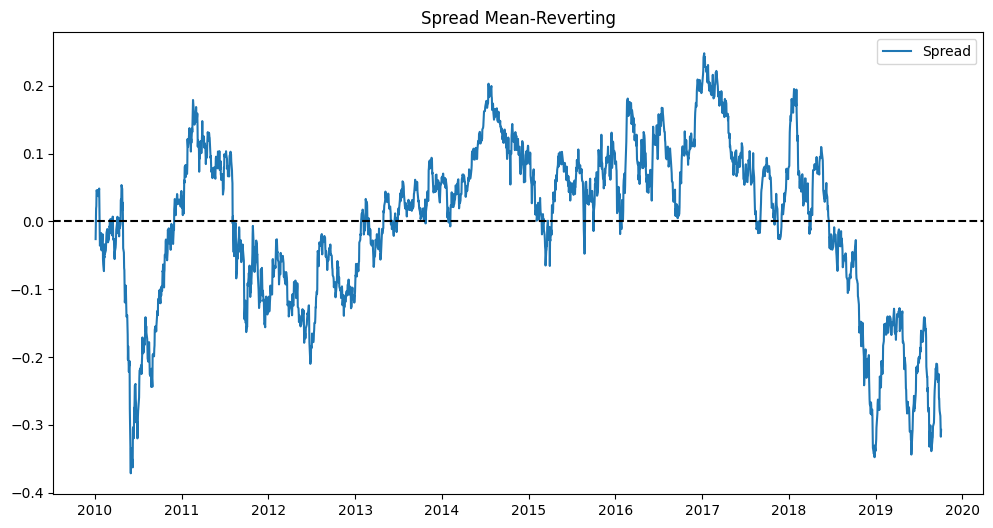

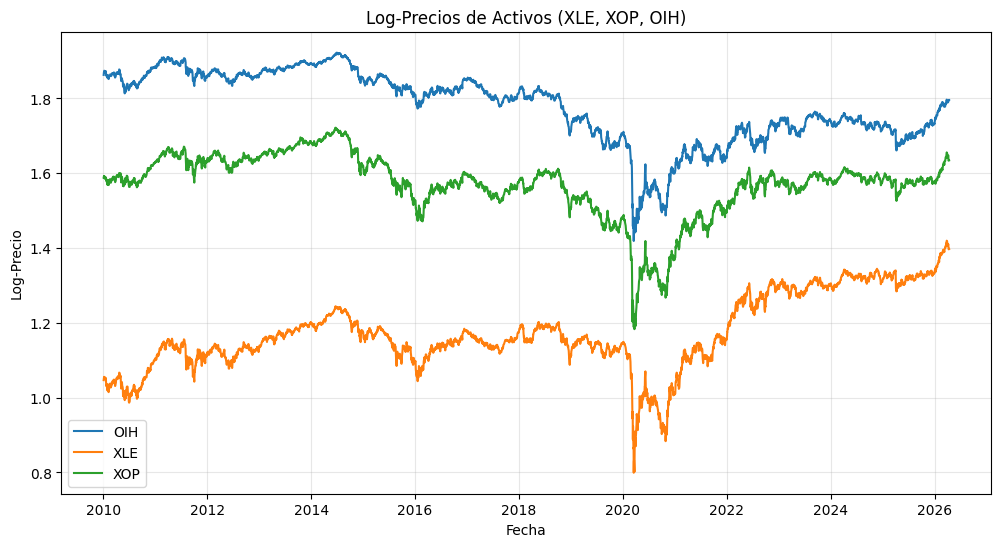

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt

tickers = ["XLE", "XOP", "OIH"]

data = yf.download(tickers, start="2010-01-01")["Close"]
data = np.log(data).dropna()

print("Shape:", data.shape)

# Split
n = len(data)

train = data.iloc[:int(0.6*n)]
test  = data.iloc[int(0.6*n):int(0.8*n)]
val   = data.iloc[int(0.8*n):]

print("Train/Test/Val:", len(train), len(test), len(val))

# Correlación
print("\nMatriz de Correlación:")
print(train.corr())

# Engle-Granger
def engle_granger(y, X):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    residuals = model.resid
    return adfuller(residuals)[1]

y_eg = train["XLE"]
X_eg = train[["XOP", "OIH"]]

eg_pvalue = engle_granger(y_eg, X_eg)

print(f"\nEngle-Granger p-value: {eg_pvalue:.4f}")
print("¿Pasa?:", eg_pvalue < 0.05)

# Johansen
result = coint_johansen(train, det_order=0, k_ar_diff=2)

print("\nJOHANSEN")
for i, stat in enumerate(result.lr1):
    print(f"r <= {i}: stat={stat:.4f}, cv95={result.cvt[i,1]}")

# Beta
beta = result.evec[:, 0]
beta = beta / beta[0]

print("\nBeta:", beta)

# Spread
spread_train = train @ beta
spread_train = spread_train - spread_train.mean()

# ADF
adf = adfuller(spread_train)

print("\nADF p-value:", adf[1])
print("¿Estacionario?:", adf[1] < 0.05)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(spread_train, label="Spread")
plt.axhline(0, linestyle="--", color="black")
plt.title("Spread Mean-Reverting")
plt.legend()
plt.show()


# Convertir a log-precios
log_prices = np.log(data)

# Limpiar datos
log_prices = log_prices.dropna()


# Gráfica de los activios individuales
plt.figure(figsize=(12,6))

for col in log_prices.columns:
    plt.plot(log_prices.index, log_prices[col], label=col)

plt.title("Log-Precios de Activos (XLE, XOP, OIH)")
plt.xlabel("Fecha")
plt.ylabel("Log-Precio")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Beta normalizado: [ 1.          4.06848482 -5.02139208]


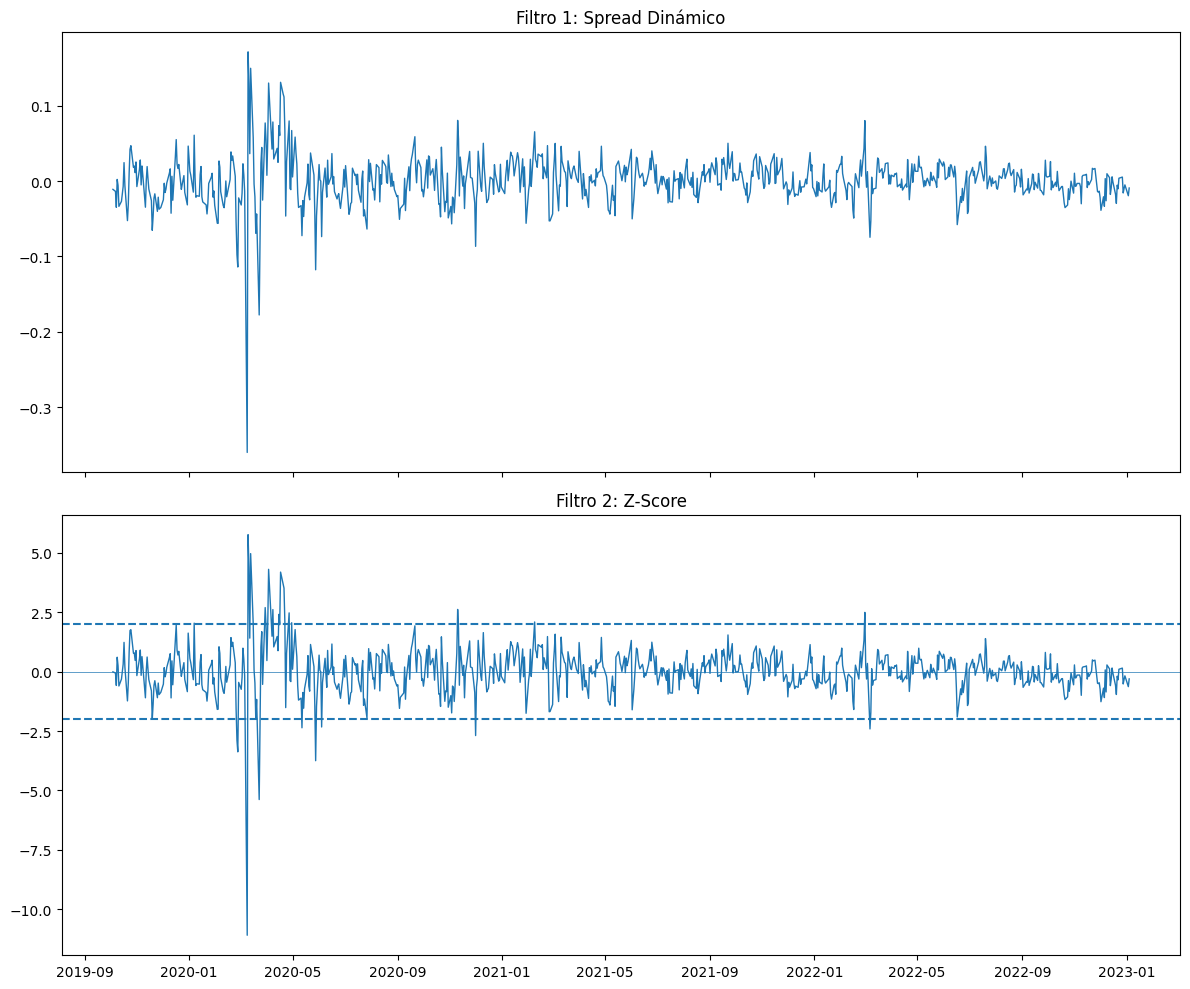

In [24]:
# Johansen → Beta Normalizado
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(train, det_order=0, k_ar_diff=2)

# Eigenvector más estacionario
idx = np.argmin(result.eig)
beta = result.evec[:, idx]

# Normalización
beta_normalized = beta / beta[0]

print("Beta normalizado:", beta_normalized)

# KALMAN (SDA)
class DualKalmanSDA:
    def __init__(self, n_assets, initial_beta):
        # Filtro 1: Estimación de Pesos
        self.beta = initial_beta  
        self.P1 = np.eye(n_assets) * 1e-2 
        self.Q1 = np.eye(n_assets) * 1e-5 
        self.R1 = 1e-3                   
        
        # Filtro 2: Dinámica del spread
        self.mu_s = 0.0
        self.P2 = 1.0
        self.Q2 = 1e-8
        self.R2 = 1e-3
        
    def update(self, price_vector):
        # Filtro 1
        P1_prior = self.P1 + self.Q1
        
        y_obs = 0
        y_pred = np.dot(price_vector, self.beta)
        error_vecm = y_obs - y_pred
        
        S1 = np.dot(price_vector, np.dot(P1_prior, price_vector.T)) + self.R1
        K1 = np.dot(P1_prior, price_vector.T) / S1
        
        self.beta = self.beta + K1 * error_vecm
        self.P1 = (np.eye(len(self.beta)) - np.outer(K1, price_vector)) @ P1_prior
        
        # Spread
        current_spread = np.dot(price_vector, self.beta)
        
        # Filtro 2
        P2_prior = self.P2 + self.Q2
        
        innovation = current_spread - self.mu_s
        
        S2 = P2_prior + self.R2
        K2 = P2_prior / S2
        
        self.mu_s = self.mu_s + K2 * innovation
        self.P2 = (1 - K2) * P2_prior
        
        std = np.sqrt(S2)
        z_score = innovation / std
        
        return self.beta.copy(), current_spread, z_score


# Procesamiento secuencial
assets_trading = ["XLE", "XOP", "OIH"]

test_data = test[assets_trading].values

k_system = DualKalmanSDA(
    n_assets=len(assets_trading),
    initial_beta=beta_normalized
)

results = []

for t in range(len(test_data)):
    b, s, z = k_system.update(test_data[t])
    
    results.append({
        'beta': b,
        'spread': s,
        'z_score': z
    })

df_kalman = pd.DataFrame(results, index=test.index)


# Ver
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Spread
ax1.plot(df_kalman['spread'], lw=1)
ax1.set_title("Filtro 1: Spread Dinámico")

# Z-score
ax2.plot(df_kalman['z_score'], lw=1)
ax2.axhline(2, linestyle="--")
ax2.axhline(-2, linestyle="--")
ax2.axhline(0, lw=0.5)
ax2.set_title("Filtro 2: Z-Score")

plt.tight_layout()
plt.show()

In [25]:
# Optimización y generación de señales
def optimize_thresholds(z_scores, spread_returns):
    """
    Realiza un Grid Search para encontrar los umbrales de entrada y salida
    que maximizan el Sharpe Ratio en el periodo de entrenamiento.
    """
    best_sharpe = -np.inf
    best_params = (2.0, 0.5)
    
    
    for z_entry in np.linspace(.3, 2, 15):
        for z_exit in np.linspace(0, .2, 5):
            pos = 0
            rets = []
            for z, r in zip(z_scores, spread_returns):
                if pos == 0 and abs(z) > z_entry:
                    pos = -np.sign(z)
                elif pos != 0 and abs(z) < z_exit:
                    pos = 0
                rets.append(pos * r)
            
            std_rets = np.std(rets)
            sharpe = np.mean(rets) / std_rets if std_rets > 0 else 0
            
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_params = (z_entry, z_exit)
                
    return best_params

def generate_signals_vecm(df_kalman, z_entry, z_exit):
    """
    Genera señales de trading basadas en el residuo del VECM normalizado (Z-score).
    """
    signals = pd.Series(0, index=df_kalman.index)
    current_pos = 0
    
    for i in range(1, len(df_kalman)):
        z = df_kalman['z_score'].iloc[i]
        
        if current_pos == 0:
            if z < -z_entry:
                current_pos = 1   # Long Spread
            elif z > z_entry:
                current_pos = -1  # Short Spread
        
        elif current_pos == 1 and z > -z_exit:
            current_pos = 0
        elif current_pos == -1 and z < z_exit:
            current_pos = 0
            
        signals.iloc[i] = current_pos
    return signals

# EJECUTAR

# 1. Optimización
z_in, z_out = optimize_thresholds(df_kalman['z_score'], df_kalman['spread'].diff().fillna(0))

# 2. Aplicación de señales
df_kalman['signal'] = generate_signals_vecm(df_kalman, z_in, z_out)

print(f"Proceso Completado con Éxito")
print(f"Parámetros óptimos encontrados: Entrada={z_in:.2f}, Salida={z_out:.2f}")

Proceso Completado con Éxito
Parámetros óptimos encontrados: Entrada=1.76, Salida=0.15


In [22]:
# Verificación de señales generadas
conteo_senales = df_kalman['signal'].value_counts()
print("Distribución de Posiciones:")
print(conteo_senales)

# Calcular retornos finales
df_kalman['port_ret'] = df_kalman['spread'].diff().fillna(0)
df_kalman['strat_ret'] = df_kalman['signal'].shift(1) * df_kalman['port_ret']

# Aplicar costos aproximados (0.125%)
# Se cobra comisión cuando la señal abre o cierra
df_kalman['trades'] = df_kalman['signal'].diff().fillna(0).abs()
df_kalman['net_ret'] = df_kalman['strat_ret'] - (df_kalman['trades'] * 0.00125)

print(f"\nRetorno Neto Acumulado: {df_kalman['net_ret'].sum():.4f}")

Distribución de Posiciones:
signal
 0    731
-1     50
 1     38
Name: count, dtype: int64

Retorno Neto Acumulado: 2.3739


In [15]:
# Spread y ADF
spread_train = train @ beta_normalized

from statsmodels.tsa.stattools import adfuller
adf_final = adfuller(spread_train)

print("Engle-Granger:", eg_pvalue)
print("ADF spread:", adf_final[1])

Engle-Granger: 0.11215176178380903
ADF spread: 0.9455883050749264


In [26]:
# Retornos
df_kalman['port_ret'] = df_kalman['spread'].diff().fillna(0)
df_kalman['strat_ret'] = df_kalman['signal'].shift(1) * df_kalman['port_ret']

# Costos
df_kalman['trades'] = df_kalman['signal'].diff().fillna(0).abs()
df_kalman['net_ret'] = df_kalman['strat_ret'] - (df_kalman['trades'] * 0.00125)

# Retorno acumulado
cum_return = df_kalman['net_ret'].sum()

# Sharpe
sharpe = df_kalman['net_ret'].mean() / df_kalman['net_ret'].std()
sharpe_anual = sharpe * np.sqrt(252)

# Sortino (downside risk)
downside_returns = df_kalman['net_ret'][df_kalman['net_ret'] < 0]
downside_std = downside_returns.std()

sortino = df_kalman['net_ret'].mean() / downside_std if downside_std > 0 else 0
sortino_anual = sortino * np.sqrt(252)

# Drawdown
cum_curve = (1 + df_kalman['net_ret']).cumprod()
rolling_max = cum_curve.cummax()
drawdown = (cum_curve - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Calmar
# Retorno anual
ret_anual = df_kalman['net_ret'].mean() * 252
calmar = ret_anual / abs(max_drawdown) if max_drawdown != 0 else 0

print("Retorno acumulado:", round(cum_return, 4))
print("Sharpe anualizado:", round(sharpe_anual, 4))
print("Sortino anualizado:", round(sortino_anual, 4))
print("Max Drawdown:", round(max_drawdown, 4))
print("Calmar Ratio:", round(calmar, 4))

Retorno acumulado: 2.3739
Sharpe anualizado: 1.9121
Sortino anualizado: 1.5319
Max Drawdown: -0.1341
Calmar Ratio: 5.4521


In [27]:
# Número total de trades
num_trades = df_kalman['trades'].sum()

# Conteo de posiciones
pos_counts = df_kalman['signal'].value_counts()

long_trades = pos_counts.get(1, 0)
short_trades = pos_counts.get(-1, 0)
neutral = pos_counts.get(0, 0)

# Proporciones
total_positions = long_trades + short_trades

long_ratio = long_trades / total_positions if total_positions > 0 else 0
short_ratio = short_trades / total_positions if total_positions > 0 else 0

# Frecuencia de operación
freq = num_trades / len(df_kalman)

print("Número total de trades:", int(num_trades))
print("Long trades:", long_trades)
print("Short trades:", short_trades)
print("Proporción Long:", round(long_ratio, 2))
print("Proporción Short:", round(short_ratio, 2))
print("Frecuencia de operación:", round(freq, 4))

Número total de trades: 46
Long trades: 38
Short trades: 50
Proporción Long: 0.43
Proporción Short: 0.57
Frecuencia de operación: 0.0562
